You are a data analyst working for a tech company closely monitoring the AI tools market. You want to understand the evolving popularity of three major AI tools, ChatGPT, Gemini, and Microsoft Copilot, and identify which tool is gaining the most traction and how they compare over time.


<img src="ai_tools.jpg" align="center"/>

You'll work with real-world time series data that captures the global interest in these tools over several weeks. Your goal is to analyze this data, uncover patterns, and provide actionable insights to help your company make informed decisions. This might include determining where to focus marketing efforts, predicting future trends, or identifying potential areas for improvement.

Are you ready to help your company stay ahead of the curve in the competitive AI tools market? Let's get started!

### The Data

The Google Trends data is available as a CSV file `ai_tools_comparison.csv`.
The data contains the number of worldwide searches for chatGpt, Gemini, and Microsoft Copilot over the past 12 months as of September 2024. 
<!--- Link to query: https://trends.google.com/trends/explore?q=chatgpt,gemini,%2Fg%2F11tsqm45vd&hl=en-US -->

In [144]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
trends = pd.read_csv('ai_tools_comparison.csv')

# Inspect the data
trends.head()

,week,chatgpt,gemini,microsoft_copilot
0,2023-08-27,56,3,1
1,2023-09-03,56,3,1
2,2023-09-10,63,3,1
3,2023-09-17,64,3,1
4,2023-09-24,66,3,1


In [145]:
# Start coding here
# Use as many cells as you need

In [146]:
trends.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   week               54 non-null     object
 1   chatgpt            54 non-null     int64 
 2   gemini             54 non-null     int64 
 3   microsoft_copilot  54 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 1.8+ KB


Which AI tool has shown the most consistent growth in interest over the observed period (the full dataset)? Save the name of the tool as most_consistent_tool of type Data type string

In [147]:
trends['week'] = pd.to_datetime(trends['week'])

In [148]:
trends.set_index('week', inplace=True)

In [149]:
growth = trends.pct_change().fillna(0).mul(100)

In [150]:
print(growth)

              chatgpt      gemini  microsoft_copilot
week                                                
2023-08-27   0.000000    0.000000           0.000000
2023-09-03   0.000000    0.000000           0.000000
2023-09-10  12.500000    0.000000           0.000000
2023-09-17   1.587302    0.000000           0.000000
2023-09-24   3.125000    0.000000           0.000000
2023-10-01   1.515152    0.000000           0.000000
2023-10-08   1.492537   33.333333           0.000000
2023-10-15   1.470588    0.000000           0.000000
2023-10-22   2.898551    0.000000         100.000000
2023-10-29  -2.816901  -25.000000           0.000000
2023-11-05   8.695652    0.000000           0.000000
2023-11-12  -5.333333    0.000000           0.000000
2023-11-19   5.633803    0.000000          50.000000
2023-11-26   6.666667    0.000000         -33.333333
2023-12-03  -1.250000  233.333333          50.000000
2023-12-10  -1.265823  -20.000000           0.000000
2023-12-17 -20.512821  -25.000000         -33.

In [151]:
df = pd.DataFrame(growth)

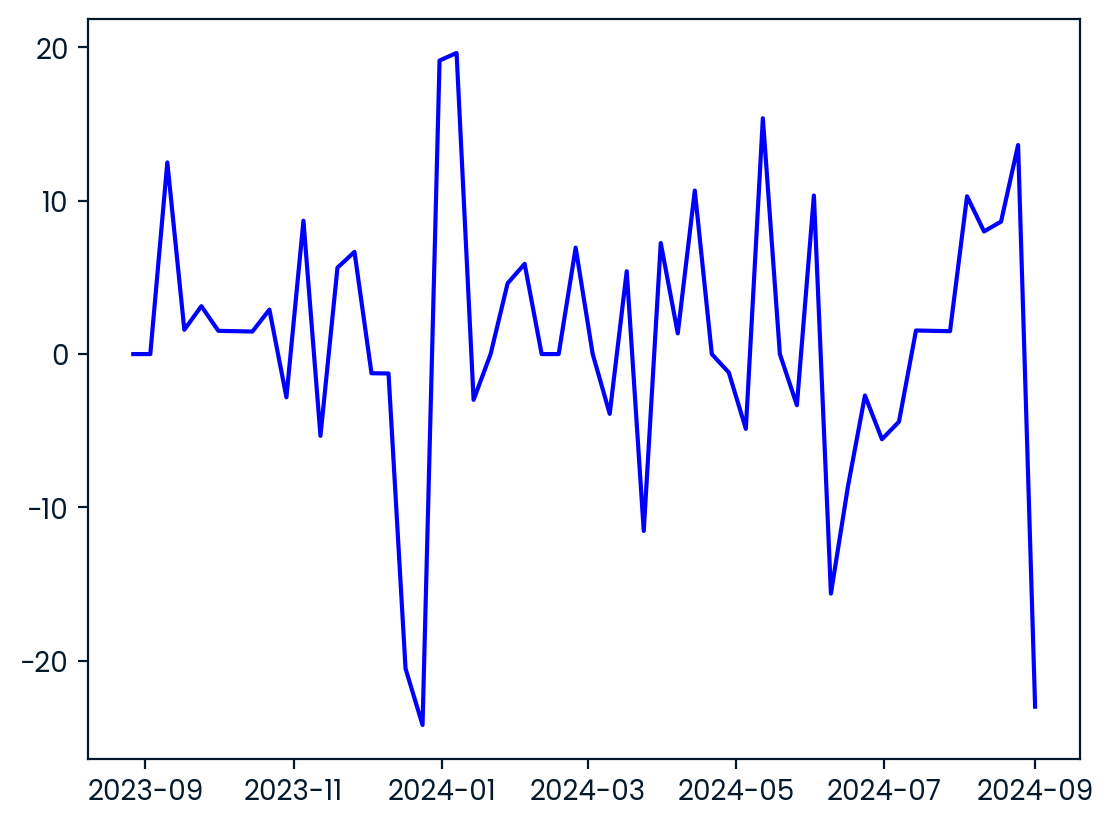

In [152]:
plt.plot(df.index, df['chatgpt'], color='blue')

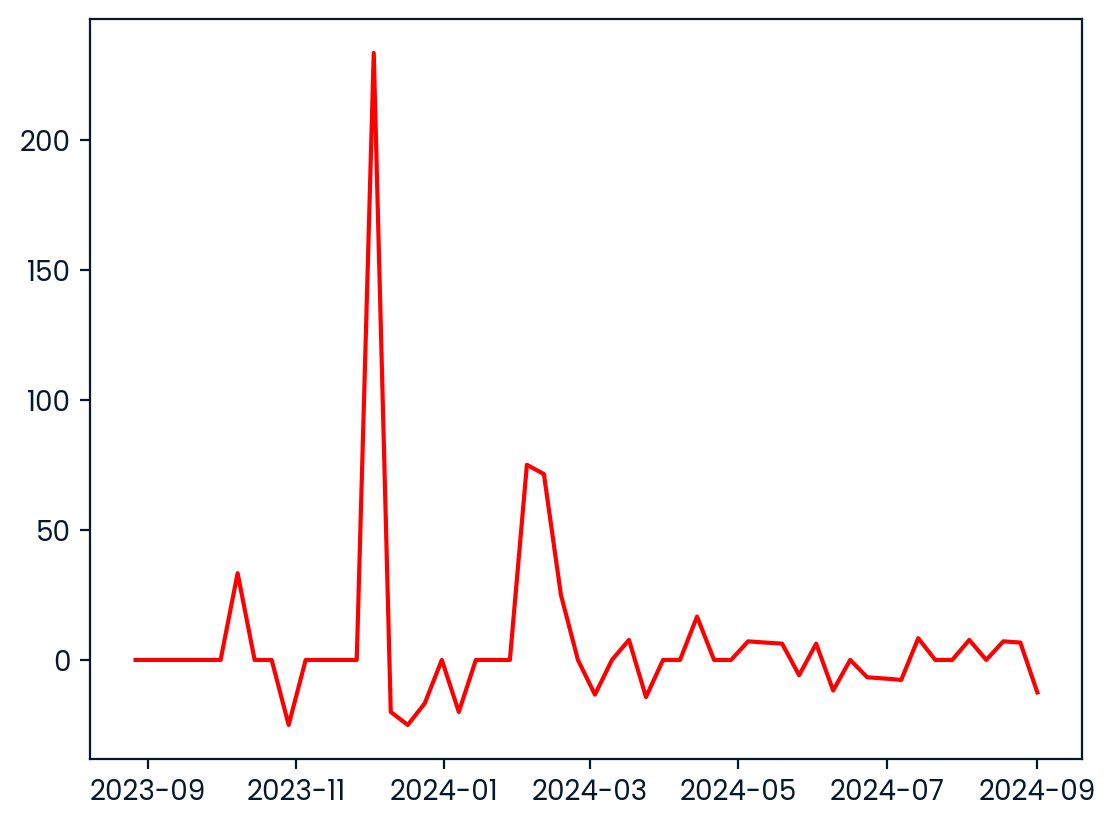

In [153]:
plt.plot(df.index, df['gemini'], label='Gemini', color='red')

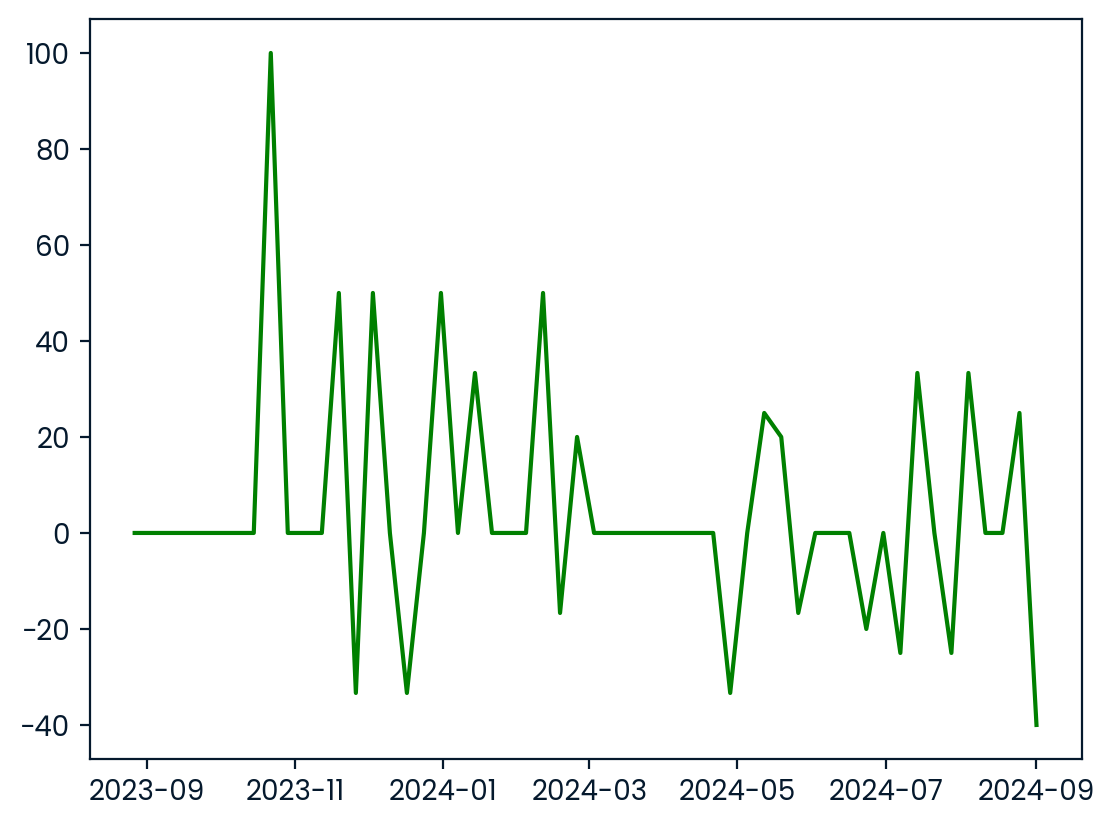

In [154]:
plt.plot(df.index, df['microsoft_copilot'], label='Copilot', color='green')

In [155]:
plt.show()

In [ ]:
most_consistent_tool = "chatgpt"

Around which month and year does ChatGPT experience its largest decline in interest?

In [157]:
print(df['chatgpt'])

week
2023-08-27     0.000000
2023-09-03     0.000000
2023-09-10    12.500000
2023-09-17     1.587302
2023-09-24     3.125000
2023-10-01     1.515152
2023-10-08     1.492537
2023-10-15     1.470588
2023-10-22     2.898551
2023-10-29    -2.816901
2023-11-05     8.695652
2023-11-12    -5.333333
2023-11-19     5.633803
2023-11-26     6.666667
2023-12-03    -1.250000
2023-12-10    -1.265823
2023-12-17   -20.512821
2023-12-24   -24.193548
2023-12-31    19.148936
2024-01-07    19.642857
2024-01-14    -2.985075
2024-01-21     0.000000
2024-01-28     4.615385
2024-02-04     5.882353
2024-02-11     0.000000
2024-02-18     0.000000
2024-02-25     6.944444
2024-03-03     0.000000
2024-03-10    -3.896104
2024-03-17     5.405405
2024-03-24   -11.538462
2024-03-31     7.246377
2024-04-07     1.351351
2024-04-14    10.666667
2024-04-21     0.000000
2024-04-28    -1.204819
2024-05-05    -4.878049
2024-05-12    15.384615
2024-05-19     0.000000
2024-05-26    -3.333333
2024-06-02    10.344828
2024-06-09 

One can see a dip in interest in ChatGPT in December 2023

Text(0, 0.5, 'Interest')

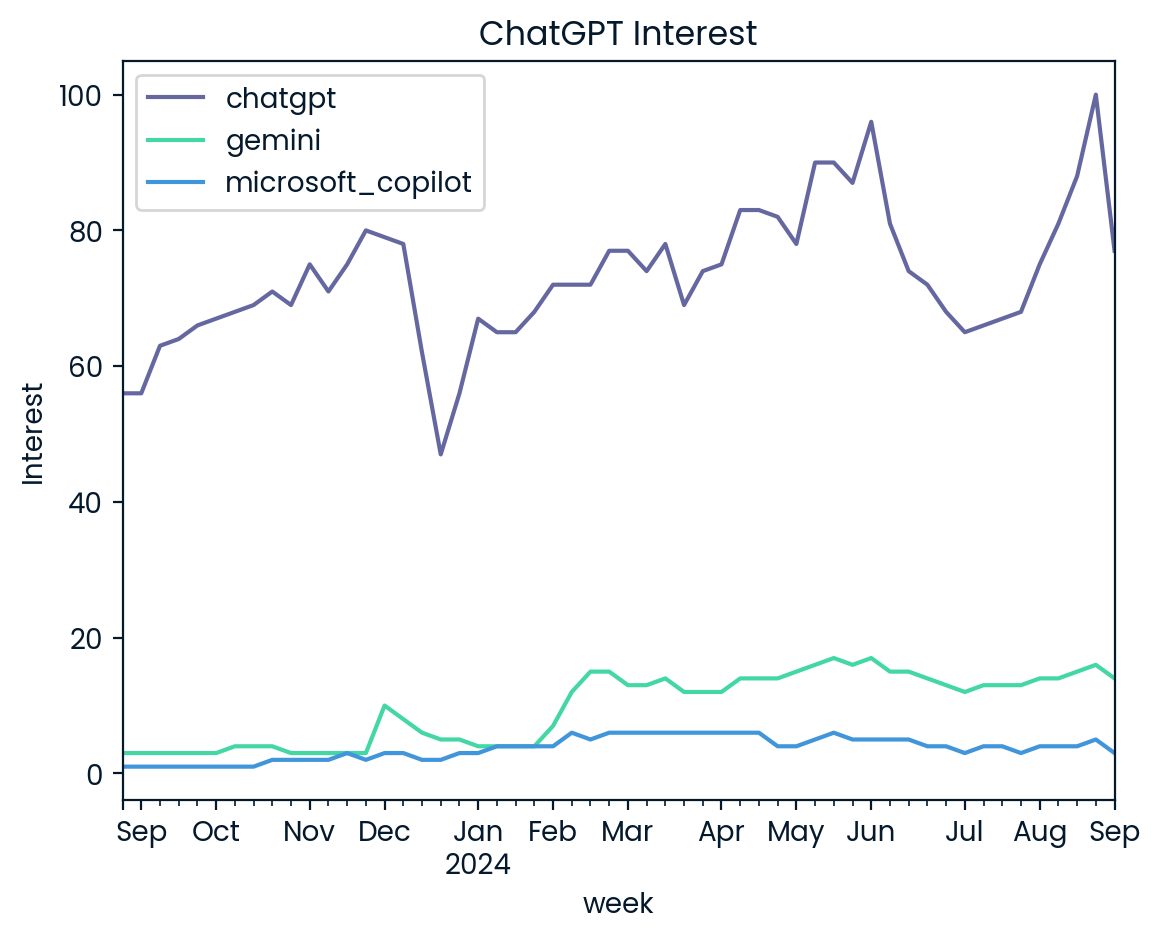

In [158]:
trends.plot(title="ChatGPT Interest")
plt.ylabel('Interest')

The line chart shows that chatGPT has its largest dip in December 2023

In [159]:
gpt_dip = "December 2023"

Explore the seasonality in the data by breaking it down into monthly averages. What month had the highest average interest across all tools? Save the month as best_month as type string.

In [160]:
monthly_average = trends.resample('M').mean()

In [161]:
print(monthly_average)

            chatgpt  gemini  microsoft_copilot
week                                          
2023-08-31    56.00    3.00               1.00
2023-09-30    62.25    3.00               1.00
2023-10-31    68.80    3.60               1.40
2023-11-30    75.25    3.00               2.25
2023-12-31    64.40    6.80               2.60
2024-01-31    66.25    4.00               3.75
2024-02-29    73.25   12.25               5.25
2024-03-31    74.40   12.80               6.00
2024-04-30    80.75   13.50               5.50
2024-05-31    86.25   16.00               5.00
2024-06-30    78.20   14.80               4.60
2024-07-31    66.50   12.75               3.50
2024-08-31    86.00   14.75               4.25
2024-09-30    77.00   14.00               3.00


May has the highest average interest across all tools

In [162]:
best_month = "May"